In [17]:
import pandas as pd
from pathlib import Path
import re
import numpy as np

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from pathlib import Path
import re
import numpy as np

In [2]:
data_dir = Path("./")

In [5]:
age_factors= [0.01, 0.1, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.5, 2]

throughputs = []
request_duration_avg = []
request_duration_p95 = []
request_duration_p99 = []

for age_factor in age_factors:
    dir = data_dir / f"factor_{age_factor}"
    for csv_path in dir.glob("*.csv"):
        df = pd.read_csv(csv_path)

        throughputs.append(df["throughput"].mean())

        request_duration_avg.append(df["request_duration_avg"].mean())
        request_duration_p95.append(df["request_duration_p95"].mean())
        request_duration_p99.append(df["request_duration_p99"].mean())

df = pd.DataFrame({
    "age_factor": age_factors,
    "throughput": throughputs,
    "request_duration_avg": request_duration_avg,
    "request_duration_p95": request_duration_p95,
    "request_duration_p99": request_duration_p99
})
df




        



,age_factor,throughput,request_duration_avg,request_duration_p95,request_duration_p99
0,0.01,128.494031,19.530879,30.314056,32.350222
1,0.10,127.653537,19.399874,28.565447,31.518743
2,0.50,125.418736,18.012765,26.868787,28.892757
3,0.60,120.164001,17.488312,24.331099,28.131122
4,0.70,119.550374,17.574399,24.290502,28.224162
5,0.80,119.868601,17.526933,24.383089,28.136922
6,0.90,121.477773,17.447557,25.038703,25.886599
7,1.00,118.080438,16.267286,23.823755,24.842888
8,1.50,116.709757,14.420028,21.862801,24.312110
9,2.00,114.836564,13.837843,20.356262,21.557951


In [19]:
priorities = [1, 10, 70, 100, 200, 300, 400, 500, 600, 700, 1500]

throughputs = []
request_duration_avg = []
request_duration_p95 = []
request_duration_p99 = []

for priority in priorities:
    dir = data_dir / f"priority_{priority}"
    for csv_path in dir.glob("*.csv"):
        df = pd.read_csv(csv_path)

        throughputs.append(df["throughput"].mean())

        request_duration_avg.append(df["request_duration_avg"].mean())
        request_duration_p95.append(df["request_duration_p95"].mean())
        request_duration_p99.append(df["request_duration_p99"].mean())

df = pd.DataFrame({
    "priority": [1, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1, 0],
    "throughput": throughputs,
    "request_duration_avg": request_duration_avg,
    "request_duration_p95": request_duration_p95,
    "request_duration_p99": request_duration_p99
})
rebatch_df = df
rebatch_df






        



,priority,throughput,request_duration_avg,request_duration_p95,request_duration_p99
0,1.0,112.748326,7.737958,9.173655,9.350745
1,0.9,116.367054,11.300010,16.922143,19.098304
2,0.8,117.917104,11.943929,21.088297,26.005637
3,0.7,118.120638,14.470454,24.578399,30.251148
4,0.6,119.255145,16.115172,26.320212,30.896560
5,0.5,122.603013,16.306083,26.015447,31.462693
6,0.4,122.760241,17.860862,26.422443,28.525235
7,0.3,123.979407,17.888112,26.541157,27.229396
8,0.2,126.172351,19.309596,28.647454,29.460842
9,0.1,127.444689,19.236535,29.773110,30.873298


In [20]:
baseline_dir = Path("/workspace/xutingl/vattention-ee/outputs_70b/req_2160_batch_8/")

rows = []

for csv_path in baseline_dir.glob("*.csv"):
    fname = csv_path.name
    m = re.search(r"layer_([0-9]+)_conf_([0-9.]+)_([a-z\-]+)_copy\.csv$", fname)
    if m:
        layer, conf, policy = m.group(1), m.group(2), m.group(3)

        if policy == "rebatching":
            continue
        if conf != "0.7":
            continue
        
        try:
            df = pd.read_csv(csv_path)
        except Exception as e:
            print(f"Error reading {csv_path}: {e}")
            continue
            
        throughput = df["throughput"].mean()
        request_duration_avg = df["request_duration_avg"].mean()
        request_duration_p95 = df["request_duration_p95"].mean()
        request_duration_p99 = df["request_duration_p99"].mean()

        rows.append({
            "policy": policy,
            "layer": layer,
            "conf": conf,
            "throughput": throughput,
            "request_duration_avg": request_duration_avg,
            "request_duration_p95": request_duration_p95,
            "request_duration_p99": request_duration_p99,
        })

df = pd.DataFrame(rows)
baseline_df = df
baseline_df

,policy,layer,conf,throughput,request_duration_avg,request_duration_p95,request_duration_p99
0,eager,50,0.7,147.431705,6.435095,7.005725,7.088079
1,latency-only,50,0.7,112.095810,7.638853,9.252235,9.378122
2,lazy,50,0.7,112.419824,7.729967,9.156016,9.333618
3,median,50,0.7,113.687224,7.887083,9.095933,9.216218
4,off,50,0.7,112.748326,7.737958,9.173655,9.350745


--- Rebatching Data ---
    priority  throughput  request_duration_avg  request_duration_p95  \
0        1.0  112.748326              7.737958              9.173655   
1        0.9  116.367054             11.300010             16.922143   
2        0.8  117.917104             11.943929             21.088297   
3        0.7  118.120638             14.470454             24.578399   
4        0.6  119.255145             16.115172             26.320212   
5        0.5  122.603013             16.306083             26.015447   
6        0.4  122.760241             17.860862             26.422443   
7        0.3  123.979407             17.888112             26.541157   
8        0.2  126.172351             19.309596             28.647454   
9        0.1  127.444689             19.236535             29.773110   
10       0.0  128.340720             19.557213             30.327040   

    request_duration_p99  
0               9.350745  
1              19.098304  
2              26.005637  
3  

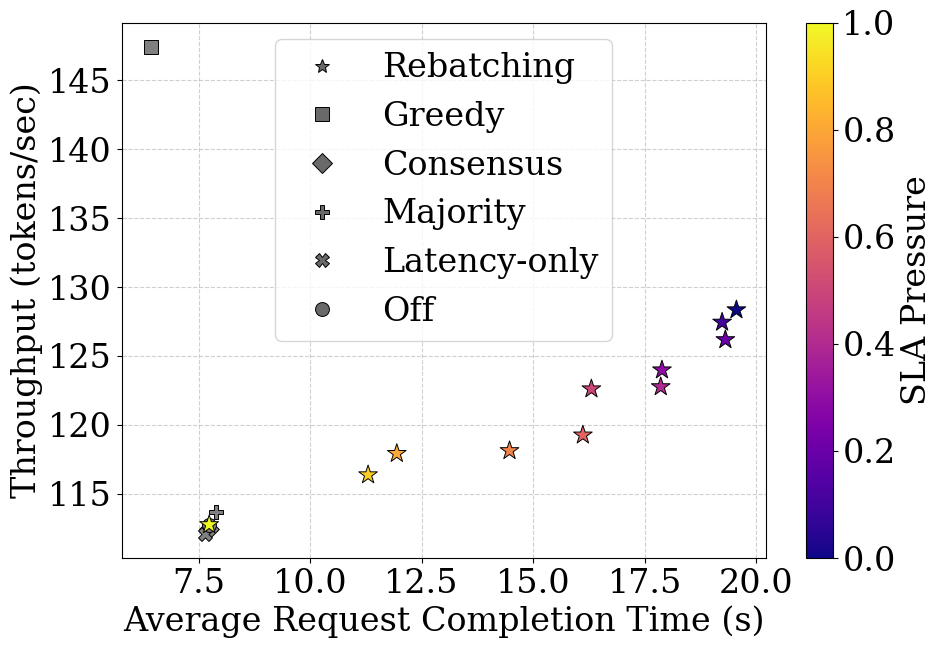

In [42]:
def plot_throughput_vs_duration(rebatch_df, baseline_df):
    """
    Generates a scatter plot of throughput vs. average request duration.

    Args:
        rebatch_data_dir (str or Path): Directory containing CSVs for the 
                                        'Rebatching' policy, organized in 
                                        subdirectories named 'priority_X'.
        baseline_data_dir (str or Path): Directory containing CSVs for other 
                                         baseline policies.
    """
    plt.rc("font", size=24, family="serif")
    # --- 1. Define Policy Styles ---
    # Markers for each policy for clear visual distinction
    policy_styles = {
        "rebatching": {"label": "Rebatching", "marker": "*"},
        "eager": {"label": "Greedy", "marker": "s"},
        "lazy": {"label": "Consensus", "marker": "D"},
        "median": {"label": "Majority", "marker": "P"},
        "latency-only": {"label": "Latency-only", "marker": "X"},
        "off": {"label": "Off", "marker": "o"},
    }

    # --- 2. Load and Process 'Rebatching' Data ---
    # rebatch_dir = Path(rebatch_data_dir)
    # priorities = sorted([float(p.name.split('_')[1]) for p in rebatch_dir.glob("priority_*")])
    
    # rebatch_rows = []
    # for priority in priorities:
    #     # Construct the path to the specific priority subdirectory
    #     priority_dir = rebatch_dir / f"priority_{priority}"
    #     # Assuming one CSV per priority folder for this example
    #     try:
    #         csv_path = next(priority_dir.glob("*.csv"))
    #         df = pd.read_csv(csv_path)
    #         rebatch_rows.append({
    #             "priority": priority,
    #             "throughput": df["throughput"].mean(),
    #             "request_duration_avg": df["request_duration_avg"].mean(),
    #         })
    #     except (StopIteration, FileNotFoundError):
    #         print(f"Warning: No CSV found for priority {priority}")
    #     except Exception as e:
    #         print(f"Error reading data for priority {priority}: {e}")

    # rebatch_df = pd.DataFrame(rebatch_rows)
    print("--- Rebatching Data ---")
    print(rebatch_df)

    # --- 3. Load and Process Baseline Policies Data ---
    # baseline_dir = Path(baseline_data_dir)
    # baseline_rows = []
    # for csv_path in baseline_dir.glob("*.csv"):
    #     m = re.search(r"layer_([0-9]+)_conf_([0-9.]+)_([a-z\-]+)_copy\.csv$", csv_path.name)
    #     if m:
    #         layer, conf, policy = m.groups()

    #         # Skip policies not in our style guide or the rebatching policy
    #         if policy not in policy_styles or policy == "rebatching":
    #             continue
    #         # Filter for a specific configuration as in the example
    #         if conf != "0.7":
    #             continue
            
    #         try:
    #             df = pd.read_csv(csv_path)
    #             baseline_rows.append({
    #                 "policy": policy,
    #                 "throughput": df["throughput"].mean(),
    #                 "request_duration_avg": df["request_duration_avg"].mean(),
    #             })
    #         except Exception as e:
    #             print(f"Error reading baseline file {csv_path}: {e}")

    # baseline_df = pd.DataFrame(baseline_rows)
    print("\n--- Baseline Policies Data ---")
    print(baseline_df)

    # --- 4. Plotting ---
    fig, ax = plt.subplots(figsize=(10, 7))

    plt.rcParams['font.family'] = 'serif'
    plt.rcParams['font.size'] = 24

    # Plot baseline policies in gray
    for policy, style in policy_styles.items():
        if policy == "rebatching":
            continue
        subdf = baseline_df[baseline_df["policy"] == policy]
        if not subdf.empty:
            ax.scatter(
                subdf["request_duration_avg"],
                subdf["throughput"],
                marker=style["marker"],
                color='gray',
                s=100,
                edgecolors='black',
                linewidths=0.7,
                label=style["label"],
                zorder=3 # Place them on top
            )

    # Plot 'Rebatching' points with a colormap
    if not rebatch_df.empty:
        # The 'plasma' colormap goes from blue/purple to orange/yellow
        scatter = ax.scatter(
            rebatch_df["request_duration_avg"],
            rebatch_df["throughput"],
            c=rebatch_df["priority"],
            cmap='plasma',
            marker=policy_styles["rebatching"]["marker"],
            s=200, # Make the stars larger
            edgecolors='black',
            linewidths=0.7,
            vmin=0,
            vmax=1,
            zorder=4
        )
        # Add a colorbar to explain the priority scale
        cbar = fig.colorbar(scatter, ax=ax)
        cbar.set_label("SLA Pressure")

    # --- 5. Final Touches and Legend ---
    # Create a manual legend for the markers
    legend_handles = [
        mlines.Line2D([], [], color='dimgrey', marker=style['marker'],
                      linestyle='None', markersize=10, label=style['label'],
                      markeredgecolor='black', markeredgewidth=0.7)
        for policy, style in policy_styles.items()
    ]
    ax.legend(handles=legend_handles, loc='upper center')

    # right arrow <--- average request completion time
    ax.set_xlabel("Average Request Completion Time (s)")
    ax.set_ylabel("Throughput (tokens/sec)")
    #ax.set_title("Throughput vs. Request Duration by Policy", fontsize=14, weight='bold')
    ax.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.savefig("throughput_vs_rct_avg.pdf", format="pdf")
    plt.show()



plot_throughput_vs_duration(rebatch_df, baseline_df)


--- Rebatching Data ---
    priority  throughput  request_duration_avg  request_duration_p95  \
0        1.0  112.748326              7.737958              9.173655   
1        0.9  116.367054             11.300010             16.922143   
2        0.8  117.917104             11.943929             21.088297   
3        0.7  118.120638             14.470454             24.578399   
4        0.6  119.255145             16.115172             26.320212   
5        0.5  122.603013             16.306083             26.015447   
6        0.4  122.760241             17.860862             26.422443   
7        0.3  123.979407             17.888112             26.541157   
8        0.2  126.172351             19.309596             28.647454   
9        0.1  127.444689             19.236535             29.773110   
10       0.0  128.340720             19.557213             30.327040   

    request_duration_p99  
0               9.350745  
1              19.098304  
2              26.005637  
3  

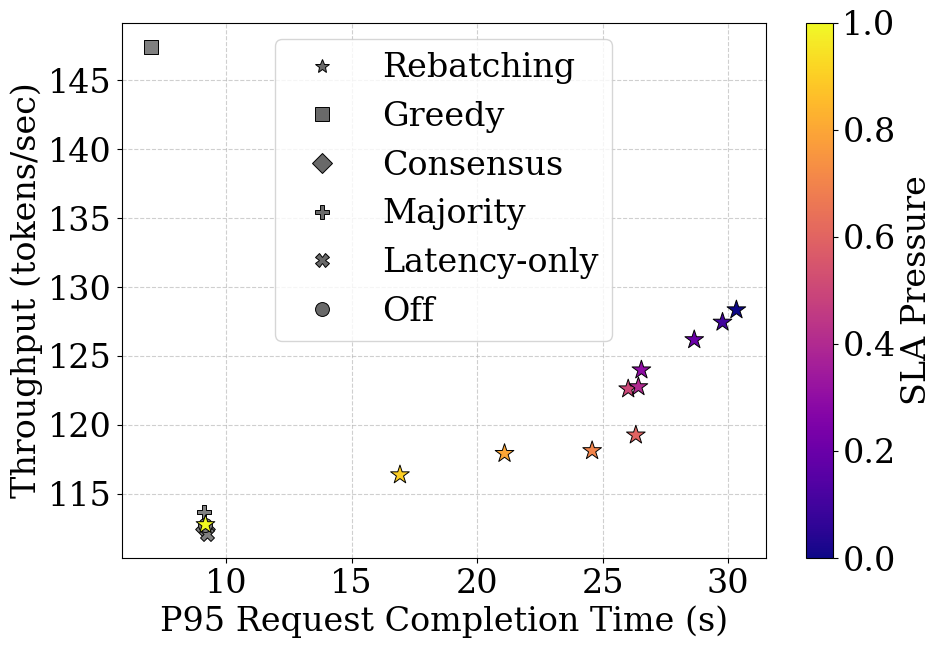

In [40]:
def plot_throughput_vs_duration(rebatch_df, baseline_df):
    """
    Generates a scatter plot of throughput vs. average request duration.

    Args:
        rebatch_data_dir (str or Path): Directory containing CSVs for the 
                                        'Rebatching' policy, organized in 
                                        subdirectories named 'priority_X'.
        baseline_data_dir (str or Path): Directory containing CSVs for other 
                                         baseline policies.
    """
    # --- 1. Define Policy Styles ---
    # Markers for each policy for clear visual distinction
    policy_styles = {
        "rebatching": {"label": "Rebatching", "marker": "*"},
        "eager": {"label": "Greedy", "marker": "s"},
        "lazy": {"label": "Consensus", "marker": "D"},
        "median": {"label": "Majority", "marker": "P"},
        "latency-only": {"label": "Latency-only", "marker": "X"},
        "off": {"label": "Off", "marker": "o"},
    }

    # --- 2. Load and Process 'Rebatching' Data ---
    # rebatch_dir = Path(rebatch_data_dir)
    # priorities = sorted([float(p.name.split('_')[1]) for p in rebatch_dir.glob("priority_*")])
    
    # rebatch_rows = []
    # for priority in priorities:
    #     # Construct the path to the specific priority subdirectory
    #     priority_dir = rebatch_dir / f"priority_{priority}"
    #     # Assuming one CSV per priority folder for this example
    #     try:
    #         csv_path = next(priority_dir.glob("*.csv"))
    #         df = pd.read_csv(csv_path)
    #         rebatch_rows.append({
    #             "priority": priority,
    #             "throughput": df["throughput"].mean(),
    #             "request_duration_avg": df["request_duration_avg"].mean(),
    #         })
    #     except (StopIteration, FileNotFoundError):
    #         print(f"Warning: No CSV found for priority {priority}")
    #     except Exception as e:
    #         print(f"Error reading data for priority {priority}: {e}")

    # rebatch_df = pd.DataFrame(rebatch_rows)
    print("--- Rebatching Data ---")
    print(rebatch_df)

    # --- 3. Load and Process Baseline Policies Data ---
    # baseline_dir = Path(baseline_data_dir)
    # baseline_rows = []
    # for csv_path in baseline_dir.glob("*.csv"):
    #     m = re.search(r"layer_([0-9]+)_conf_([0-9.]+)_([a-z\-]+)_copy\.csv$", csv_path.name)
    #     if m:
    #         layer, conf, policy = m.groups()

    #         # Skip policies not in our style guide or the rebatching policy
    #         if policy not in policy_styles or policy == "rebatching":
    #             continue
    #         # Filter for a specific configuration as in the example
    #         if conf != "0.7":
    #             continue
            
    #         try:
    #             df = pd.read_csv(csv_path)
    #             baseline_rows.append({
    #                 "policy": policy,
    #                 "throughput": df["throughput"].mean(),
    #                 "request_duration_avg": df["request_duration_avg"].mean(),
    #             })
    #         except Exception as e:
    #             print(f"Error reading baseline file {csv_path}: {e}")

    # baseline_df = pd.DataFrame(baseline_rows)
    print("\n--- Baseline Policies Data ---")
    print(baseline_df)

    # --- 4. Plotting ---
    fig, ax = plt.subplots(figsize=(10, 7))

    plt.rcParams['font.family'] = 'serif'
    plt.rcParams['font.size'] = 24

    # Plot baseline policies in gray
    for policy, style in policy_styles.items():
        if policy == "rebatching":
            continue
        subdf = baseline_df[baseline_df["policy"] == policy]
        if not subdf.empty:
            ax.scatter(
                subdf["request_duration_p95"],
                subdf["throughput"],
                marker=style["marker"],
                color='gray',
                s=100,
                edgecolors='black',
                linewidths=0.7,
                label=style["label"],
                zorder=3 # Place them on top
            )

    # Plot 'Rebatching' points with a colormap
    if not rebatch_df.empty:
        # The 'plasma' colormap goes from blue/purple to orange/yellow
        scatter = ax.scatter(
            rebatch_df["request_duration_p95"],
            rebatch_df["throughput"],
            c=rebatch_df["priority"],
            cmap='plasma',
            marker=policy_styles["rebatching"]["marker"],
            s=200, # Make the stars larger
            edgecolors='black',
            linewidths=0.7,
            vmin=0,
            vmax=1,
            zorder=4
        )
        # Add a colorbar to explain the priority scale
        cbar = fig.colorbar(scatter, ax=ax)
        cbar.set_label("SLA Pressure")

    # --- 5. Final Touches and Legend ---
    # Create a manual legend for the markers
    legend_handles = [
        mlines.Line2D([], [], color='dimgrey', marker=style['marker'],
                      linestyle='None', markersize=10, label=style['label'],
                      markeredgecolor='black', markeredgewidth=0.7)
        for policy, style in policy_styles.items()
    ]
    ax.legend(handles=legend_handles, loc='upper center')

    # right arrow <--- average request completion time
    ax.set_xlabel("P95 Request Completion Time (s)")
    ax.set_ylabel("Throughput (tokens/sec)")
    #ax.set_title("Throughput vs. Request Duration by Policy", fontsize=14, weight='bold')
    ax.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.savefig("throughput_vs_rct_p95.pdf", format="pdf")
    plt.show()



plot_throughput_vs_duration(rebatch_df, baseline_df)
